# Data Loader

Load and flatten the param sweep JSON files into a tidy table.

In [116]:
from pathlib import Path
import json
import re
from datetime import datetime
import scienceplots
import matplotlib.pyplot as plt
plt.style.use('science')

BASE_DIR = Path("/u/halle/rsim/home_at/projects/Bachelorarbeit/binpacking/data_analysis/binpacking_settings/param_sweep")

if not BASE_DIR.exists():
    raise FileNotFoundError(f"BASE_DIR not found: {BASE_DIR}")

FILENAME_RE = re.compile(r"^(?P<kind>[^_]+)_(?P<label>.+)_(?P<ts>\d{8}_\d{6})\.json$")


def read_json(path: Path) -> dict:
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def split_family_variant(group: str):
    if not group:
        return None, None
    parts = group.split("_", 1)
    family = parts[0]
    variant = parts[1] if len(parts) > 1 else None
    return family, variant


def parse_sweep_name(name: str) -> dict:
    prefix = name
    off_pct = None
    on_pct = None
    if "_off" in name and "_on" in name:
        prefix, rest = name.split("_off", 1)
        off_str, on_str = rest.split("_on", 1)
        try:
            off_pct = int(off_str)
            on_pct = int(on_str)
        except ValueError:
            off_pct = None
            on_pct = None
    family, variant = split_family_variant(prefix)
    return {
        "sweep": name,
        "sweep_group": prefix,
        "family": family,
        "variant": variant,
        "off_pct": off_pct,
        "on_pct": on_pct,
    }


def parse_filename(path: Path) -> dict:
    m = FILENAME_RE.match(path.name)
    if not m:
        return {"kind": None, "label": None, "run_id": None, "run_dt": None}
    run_id = m.group("ts")
    try:
        run_dt = datetime.strptime(run_id, "%Y%m%d_%H%M%S")
    except ValueError:
        run_dt = None
    return {
        "kind": m.group("kind"),
        "label": m.group("label"),
        "run_id": run_id,
        "run_dt": run_dt,
    }


def split_label(label: str):
    if not label:
        return None, None
    if "+" in label:
        return label.split("+", 1)
    return label, None


def flatten_record(data: dict, path: Path) -> dict:
    agg = data.get("aggregate", {})
    problem = data.get("problem", {})
    rel = path.relative_to(BASE_DIR)
    sweep_meta = parse_sweep_name(rel.parts[0]) if rel.parts else {}
    name_meta = parse_filename(path)
    pipeline = data.get("pipeline") or name_meta.get("label")
    offline_short, online_short = split_label(pipeline)
    return {
        "file": path.name,
        "path": str(path),
        **sweep_meta,
        **name_meta,
        "scenario": data.get("scenario"),
        "scenario_description": data.get("scenario_description"),
        "pipeline": pipeline,
        "offline_solver": data.get("offline_solver"),
        "online_policy": data.get("online_policy"),
        "offline_short": offline_short,
        "online_short": online_short,
        "seed_count": data.get("seed_count"),
        "total_objective_mean": data.get("total_objective_mean", agg.get("total_objective_mean")),
        "offline_objective_mean": agg.get("offline_objective_mean"),
        "online_objective_mean": agg.get("online_objective_mean"),
        "offline_runtime_mean": agg.get("offline_runtime_mean"),
        "online_runtime_mean": agg.get("online_runtime_mean"),
        "runtime_mean": agg.get("runtime_mean"),
        "offline_failures": agg.get("offline_failures"),
        "online_failures": agg.get("online_failures"),
        "failures": agg.get("failures"),
        "N": problem.get("N"),
        "M_off": problem.get("M_off"),
        "M_on": problem.get("M_on"),
        "dimensions": problem.get("dimensions"),
    }


def load_results(base_dir: Path = BASE_DIR):
    records = []
    for path in sorted(base_dir.rglob("*.json")):
        records.append(flatten_record(read_json(path), path))
    return records


records = load_results()
len(records)


78

In [117]:
try:
    import pandas as pd

    df = pd.DataFrame(records)
    if df.empty:
        df_eval = None
        df_opt = None
        print("No records loaded. Check BASE_DIR or records.")
    else:
        offline_map = {
            "cabfd": "CaBfd",
            "util": "UtilDecr",
            "binpacking_milp": "MILP",
            "full_horizon": "Benchmark",
        }
        online_map = {
            "primal_dual": "SimBase",
            "dynamic_learning": "DL",
            "cost_best_fit": "CaBf",
            'rolling_horizon_milp':'RollingMILP'
        }

        def pretty_pipeline(label):
            if not isinstance(label, str) or not label:
                return label
            if "+" in label:
                off_raw, on_raw = (part.strip() for part in label.split("+", 1))
                off_name = offline_map.get(off_raw, off_raw)
                on_name = online_map.get(on_raw, on_raw)
                return f"{off_name} + {on_name}"
            return offline_map.get(label, label)

        df["offline_short_raw"] = df["offline_short"]
        df["online_short_raw"] = df["online_short"]
        df["pipeline_raw"] = df["pipeline"]

        df["offline_short"] = df["offline_short"].map(offline_map).fillna(df["offline_short"])
        df["online_short"] = df["online_short"].map(online_map).fillna(df["online_short"])
        df["pipeline"] = df["pipeline"].apply(pretty_pipeline)

        df_eval = df[df["kind"] == "eval"].copy()
        df_opt = df[df["kind"] == "optimal"].copy()
    df.head()
except ImportError:
    df = None
    df_eval = None
    df_opt


In [118]:
if df_eval is not None and df_opt is not None:
    df_eval_completed = df_eval[
        (df_eval["offline_failures"].fillna(0) == 0)
        & (df_eval["online_failures"].fillna(0) == 0)
    ].copy()

    df_opt_key = df_opt[["sweep", "run_id", "scenario", "total_objective_mean"]].rename(
        columns={"total_objective_mean": "optimal_objective_mean"}
    )
    df_ratio_base = df_eval_completed.merge(df_opt_key, on=["sweep", "run_id", "scenario"], how="left")

    keep_base = ["family", "variant", "sweep", "off_pct", "on_pct"]

    df_ratio_offline = df_ratio_base[keep_base + ["offline_short", "offline_objective_mean", "optimal_objective_mean"]].rename(
        columns={
            "offline_short": "algorithm",
            "offline_objective_mean": "objective_mean",
        }
    )
    df_ratio_offline["competitive_ratio"] = (
        df_ratio_offline["objective_mean"] / df_ratio_offline["optimal_objective_mean"]
    )

    df_ratio_online = df_ratio_base[keep_base + ["online_short", "online_objective_mean", "optimal_objective_mean"]].rename(
        columns={
            "online_short": "algorithm",
            "online_objective_mean": "objective_mean",
        }
    )
    df_ratio_online["competitive_ratio"] = (
        df_ratio_online["objective_mean"] / df_ratio_online["optimal_objective_mean"]
    )

    df_ratio_hybrid = df_ratio_base[keep_base + ["pipeline", "total_objective_mean", "optimal_objective_mean"]].rename(
        columns={
            "pipeline": "algorithm",
            "total_objective_mean": "objective_mean",
        }
    )
    df_ratio_hybrid["competitive_ratio"] = (
        df_ratio_hybrid["objective_mean"] / df_ratio_hybrid["optimal_objective_mean"]
    )
else:
    df_ratio_offline = None
    df_ratio_online = None
    df_ratio_hybrid = None


In [119]:
if df_eval is not None and df_opt is not None:
    df_opt_key = df_opt[["sweep", "run_id", "scenario", "total_objective_mean"]].rename(
        columns={"total_objective_mean": "optimal_objective_mean"}
    )
    df_ratio_base_all = df_eval.merge(df_opt_key, on=["sweep", "run_id", "scenario"], how="left")
    df_ratio_base_all = df_ratio_base_all.copy()
    df_ratio_base_all["competitive_ratio"] = (
        df_ratio_base_all["total_objective_mean"] / df_ratio_base_all["optimal_objective_mean"]
    )

    df_baseline = df_ratio_base_all[df_ratio_base_all["family"] == "baseline"].copy()

    denom = df_baseline["M_off"].fillna(0) + df_baseline["M_on"].fillna(0)
    df_baseline["offline_pct"] = (
        (df_baseline["M_off"] / denom) * 100
    ).where(denom > 0)

    df_baseline["total_failures"] = (
        df_baseline["offline_failures"].fillna(0) + df_baseline["online_failures"].fillna(0)
    )
    df_baseline["seed_count"] = df_baseline["seed_count"].fillna(0)

    grouped = (
        df_baseline.groupby(["offline_pct", "offline_short", "online_short"], dropna=False)
        .agg(
            expected_cr=("competitive_ratio", "mean"),
            failure_count=("total_failures", "sum"),
            seed_count=("seed_count", "sum"),
        )
        .reset_index()
    )

    grouped["failure_rate"] = grouped["failure_count"] / grouped["seed_count"].replace(
        {0: pd.NA}
    )

    df_baseline_expected = grouped.rename(
        columns={
            "offline_short": "offline_algorithm",
            "online_short": "online_algorithm",
        }
    )[[
        "offline_pct",
        "offline_algorithm",
        "online_algorithm",
        "expected_cr",
        "failure_rate",
    ]]
    df_baseline_expected["offline_pct"] = df_baseline_expected["offline_pct"].round(0).astype("Int64")
else:
    df_baseline_expected = None



In [120]:
df_baseline_expected

,offline_pct,offline_algorithm,online_algorithm,expected_cr,failure_rate
0,0,CaBfd,CaBf,1.007516,0.32
1,0,CaBfd,DL,1.008479,0.16
2,0,CaBfd,RollingMILP,1.004710,0.32
3,0,CaBfd,SimBase,0.998765,0.04
4,0,MILP,CaBf,1.007516,0.32
...,...,...,...,...,...
67,80,MILP,SimBase,1.006794,0.10
68,80,UtilDecr,CaBf,1.003769,0.06
69,80,UtilDecr,DL,1.003688,0.06
70,80,UtilDecr,RollingMILP,1.003875,0.14


In [121]:
%config InlineBackend.figure_format = "retina"
%config InlineBackend.figure_format = "png"
%config InlineBackend.print_figure_kwargs = {"dpi": 200}


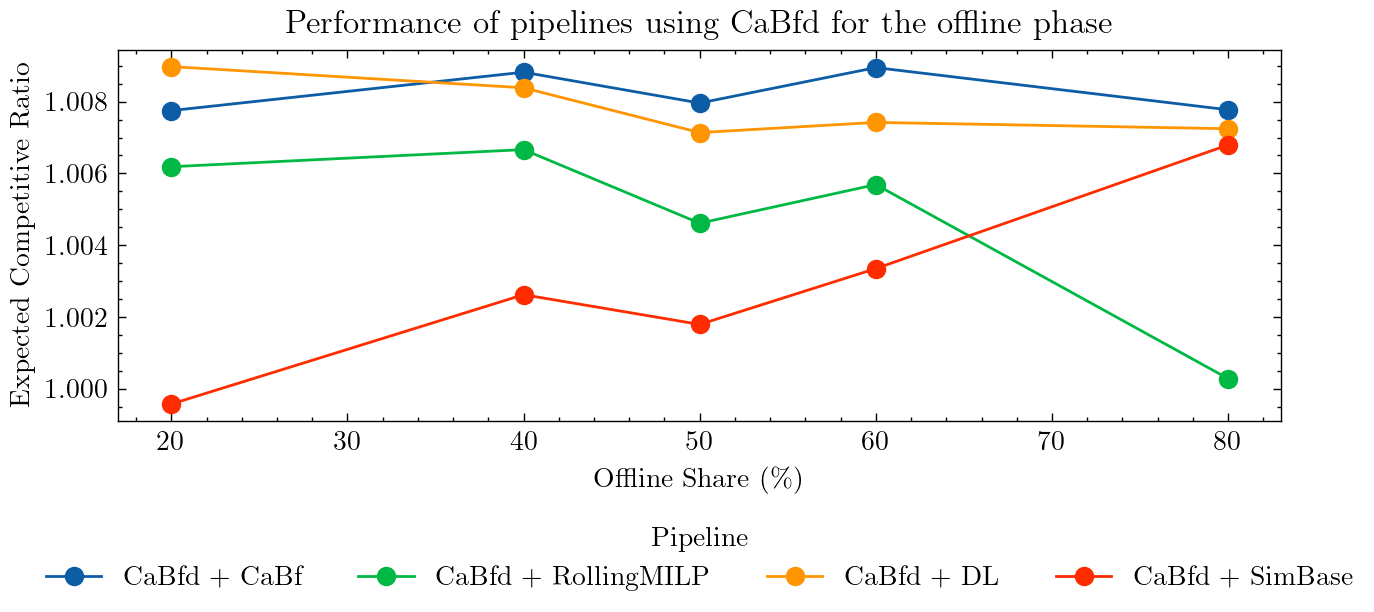

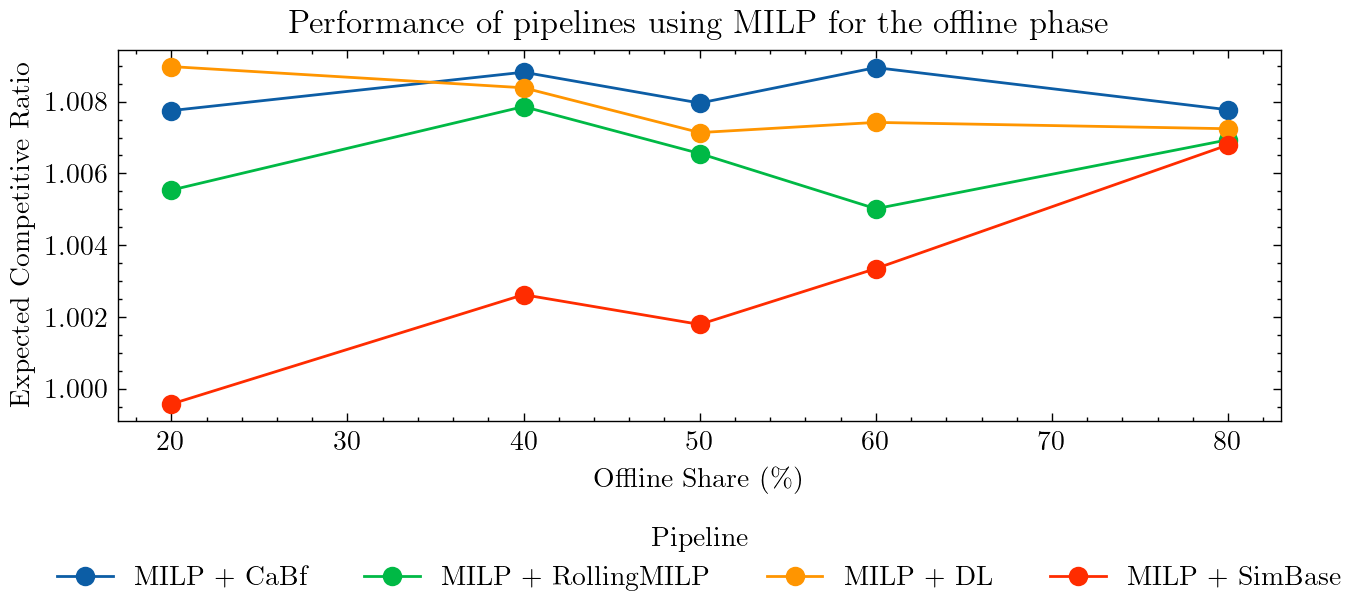

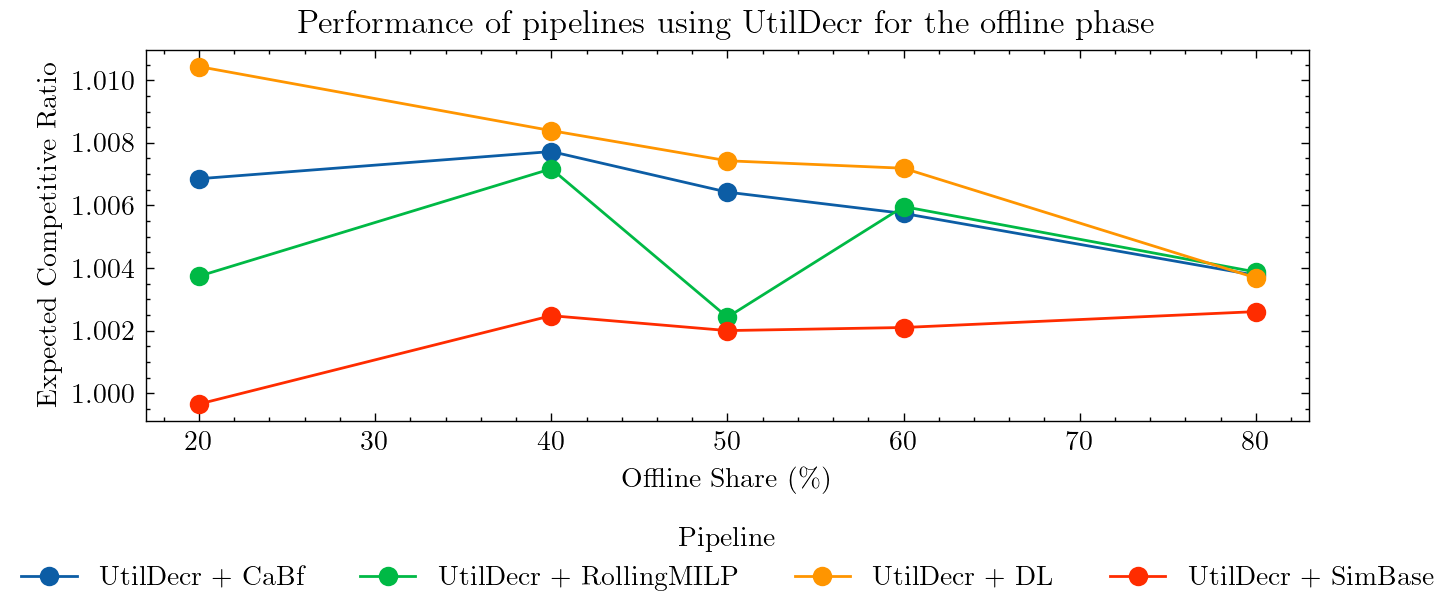

In [122]:
if df_baseline_expected is not None:
    df_plot = df_baseline_expected[
        df_baseline_expected["offline_pct"].gt(0).fillna(False)
    ].copy()

    offline_order = ["CaBfd", "MILP", "UtilDecr"]
    online_order = ["CaBf", "RollingMILP", "DL", "SimBase"]

    df_plot["offline_algorithm"] = pd.Categorical(
        df_plot["offline_algorithm"], categories=offline_order, ordered=True
    )
    df_plot["online_algorithm"] = pd.Categorical(
        df_plot["online_algorithm"], categories=online_order, ordered=True
    )
    df_plot = df_plot.sort_values(
        ["offline_algorithm", "online_algorithm", "offline_pct"]
    )

    for offline in offline_order:
        df_sub = df_plot[df_plot["offline_algorithm"] == offline].copy()
        if df_sub.empty:
            continue

        df_sub["pipeline"] = (
            df_sub["offline_algorithm"].astype(str)
            + " + "
            + df_sub["online_algorithm"].astype(str)
        )

        fig, ax = plt.subplots(figsize=(7.5, 3.2))
        for pipeline, df_pipe in df_sub.groupby("pipeline", sort=False):
            ax.plot(
                df_pipe["offline_pct"],
                df_pipe["expected_cr"],
                marker="o",
                label=pipeline,
            )

        ax.set_title(f"Performance of pipelines using {offline} for the offline phase")
        ax.set_xlabel(r"Offline Share (\%)")
        ax.set_ylabel("Expected Competitive Ratio")
        ncol = max(1, df_sub["pipeline"].nunique())
        ax.legend(
            title="Pipeline",
            ncol=ncol,
            loc="upper center",
            bbox_to_anchor=(0.5, -0.22),
        )
        fig.subplots_adjust(bottom=0.3)


In [123]:
# df_tbl vorbereiten wie gehabt
df_tbl = df_baseline_expected[
    df_baseline_expected["offline_pct"].gt(0).fillna(False)
].copy()
df_tbl = df_tbl.pivot_table(
    index="offline_pct",
    columns=["offline_algorithm", "online_algorithm"],
    values="expected_cr",
    aggfunc="mean",
).sort_index()

df_tbl.index.name = r"Offline share (\%)"

offline_order = ["CaBfd", "MILP", "UtilDecr"]
latex_blocks = {}

for offline in offline_order:
    sub = df_tbl.xs(offline, level=0, axis=1)
    sub.columns.name = "Online algorithm"
    latex_blocks[offline] = sub.to_latex(
        float_format="%.3f",
        escape=True,
        column_format="lccc",
        caption=f"Expected competitive ratio ({offline})",
        label=f"tab:expected_cr_{offline.lower()}",
        bold_rows=True,
    )

# Ausgabe (oder print einzeln)
for k, v in latex_blocks.items():
    print(v)
    print("\n")


\begin{table}
\caption{Expected competitive ratio (CaBfd)}
\label{tab:expected_cr_cabfd}
\begin{tabular}{lccc}
\toprule
Online algorithm & CaBf & DL & RollingMILP & SimBase \\
Offline share (\%) &  &  &  &  \\
\midrule
\textbf{20} & 1.008 & 1.009 & 1.006 & 1.000 \\
\textbf{40} & 1.009 & 1.008 & 1.007 & 1.003 \\
\textbf{50} & 1.008 & 1.007 & 1.005 & 1.002 \\
\textbf{60} & 1.009 & 1.007 & 1.006 & 1.003 \\
\textbf{80} & 1.008 & 1.007 & 1.000 & 1.007 \\
\bottomrule
\end{tabular}
\end{table}



\begin{table}
\caption{Expected competitive ratio (MILP)}
\label{tab:expected_cr_milp}
\begin{tabular}{lccc}
\toprule
Online algorithm & CaBf & DL & RollingMILP & SimBase \\
Offline share (\%) &  &  &  &  \\
\midrule
\textbf{20} & 1.008 & 1.009 & 1.006 & 1.000 \\
\textbf{40} & 1.009 & 1.008 & 1.008 & 1.003 \\
\textbf{50} & 1.008 & 1.007 & 1.007 & 1.002 \\
\textbf{60} & 1.009 & 1.007 & 1.005 & 1.003 \\
\textbf{80} & 1.008 & 1.007 & 1.007 & 1.007 \\
\bottomrule
\end{tabular}
\end{table}



\begin{table